In [2]:
import os
print("Current Folder:", os.getcwd())
print("Files in this folder:", os.listdir())

Current Folder: c:\Users\Admin\-AI-Powered-Crop-Yield-Prediction-and-Agricultural-Productivity-Intelligence-Platform\docs
Files in this folder: ['dataset_report.md', 'EDA_DOC_report.md', 'EDA_Milestone2.ipynb', 'EDA_Presentation.ipynb', 'Milestone1&Milestone2_completion_report.md', 'system_architecture.md']


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for the YieldSense AI theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("crest")
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Check the number of rows/columns, data types, and look for missing data
df.info()

# Get a quick statistical summary (average, min, max) of the numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    str    
 1   region                500 non-null    str    
 2   crop_type             500 non-null    str    
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    str    
 10  fertilizer_type       500 non-null    str    
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    str    
 13  harvest_date          500 non-null    str    
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  500 non-null

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.03014,26.586980,119.496000,4032.92694,22.442473,80.392248,0.602060
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.69167,13.202429,16.798046,1174.43304,7.283492,5.910664,0.175402
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.01000,5.050000,90.000000,2023.56000,10.004243,70.020021,0.300000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.66750,14.945000,105.750000,2994.82000,16.263202,75.374713,0.447500
50%,25.855000,6.530000,24.655000,191.545000,65.685000,6.99500,25.980000,119.000000,4071.69000,21.981743,80.650284,0.610000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.47000,38.005000,134.000000,5062.11000,28.528948,85.654629,0.750000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.00000,49.940000,150.000000,5998.29000,34.981531,89.991901,0.900000


In [5]:
# 1. Check how many missing values exist in each column
print("Missing values before cleaning:\n", df.isnull().sum())

# 2. Remove any exact duplicate rows
df = df.drop_duplicates()

# 3. Drop rows with missing values to ensure our data is complete
df = df.dropna()

# 4. Check the final size of our dataset after cleaning (rows, columns)
print("\nDataset size after cleaning:", df.shape)

Missing values before cleaning:
 farm_id                   0
region                    0
crop_type                 0
soil_moisture_%           0
soil_pH                   0
temperature_C             0
rainfall_mm               0
humidity_%                0
sunlight_hours            0
irrigation_type         150
fertilizer_type           0
pesticide_usage_ml        0
sowing_date               0
harvest_date              0
total_days                0
yield_kg_per_hectare      0
sensor_id                 0
timestamp                 0
latitude                  0
longitude                 0
NDVI_index                0
crop_disease_status     130
dtype: int64

Dataset size after cleaning: (255, 22)


In [12]:
# Check for null values
missing_values = df.isnull().sum()
print("Missing Values per Feature:")
print(missing_values[missing_values > 0] if missing_values.any() else "No missing values found! Data is clean.")

# Display summary statistics
display(df.describe().T)

Missing Values per Feature:
No missing values found! Data is clean.


,count,mean,std,min,25%,50%,75%,max
soil_moisture_%,255.0,25.954745,10.053869,10.160000,17.550000,25.510000,33.960000,44.980000
soil_pH,255.0,6.520314,0.591320,5.510000,6.000000,6.560000,7.020000,7.500000
temperature_C,255.0,24.654980,5.376050,15.010000,20.115000,24.510000,29.080000,34.840000
rainfall_mm,255.0,184.639294,72.946696,50.170000,121.540000,196.890000,244.240000,298.960000
humidity_%,255.0,65.912706,14.592423,40.230000,53.115000,66.770000,79.245000,90.000000
sunlight_hours,255.0,7.094392,1.736487,4.020000,5.560000,7.150000,8.480000,10.000000
pesticide_usage_ml,255.0,26.540039,13.298560,5.070000,15.230000,25.720000,37.785000,49.910000
total_days,255.0,118.654902,17.422679,90.000000,102.500000,118.000000,134.000000,150.000000
yield_kg_per_hectare,255.0,3990.669255,1182.616843,2023.560000,2907.665000,3992.540000,5030.980000,5998.290000
latitude,255.0,22.629073,7.133664,10.066893,16.783396,22.165819,28.802918,34.899235


In [7]:
# Print out all the column names in the dataset as a list
print(df.columns.tolist())

['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours', 'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml', 'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare', 'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index', 'crop_disease_status']


In [18]:
print(df.columns)

Index(['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH',
       'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours',
       'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml',
       'sowing_date', 'harvest_date', 'total_days', 'yield_kg_per_hectare',
       'sensor_id', 'timestamp', 'latitude', 'longitude', 'NDVI_index',
       'crop_disease_status'],
      dtype='str')


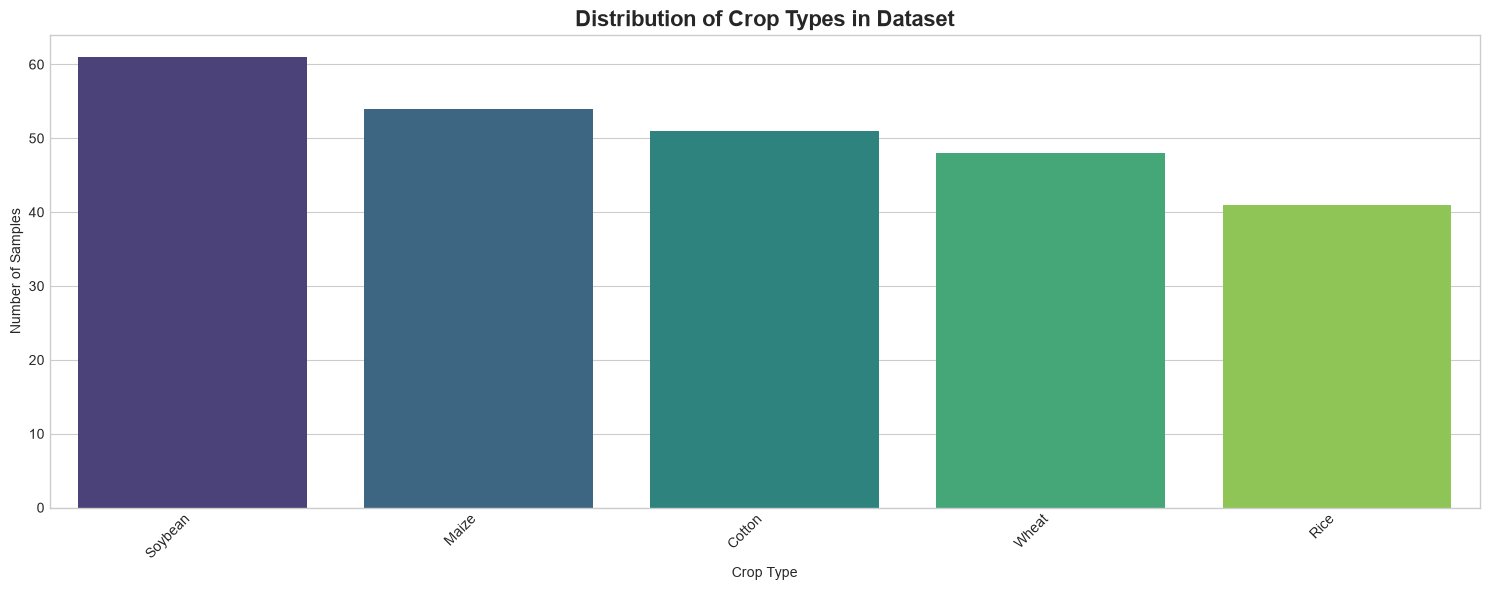

In [19]:
plt.figure(figsize=(15, 6))
# Using 'crop_type' instead of 'label'
sns.countplot(data=df, x='crop_type', order=df['crop_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Crop Types in Dataset', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Samples')
plt.xlabel('Crop Type')
plt.tight_layout()
plt.show()

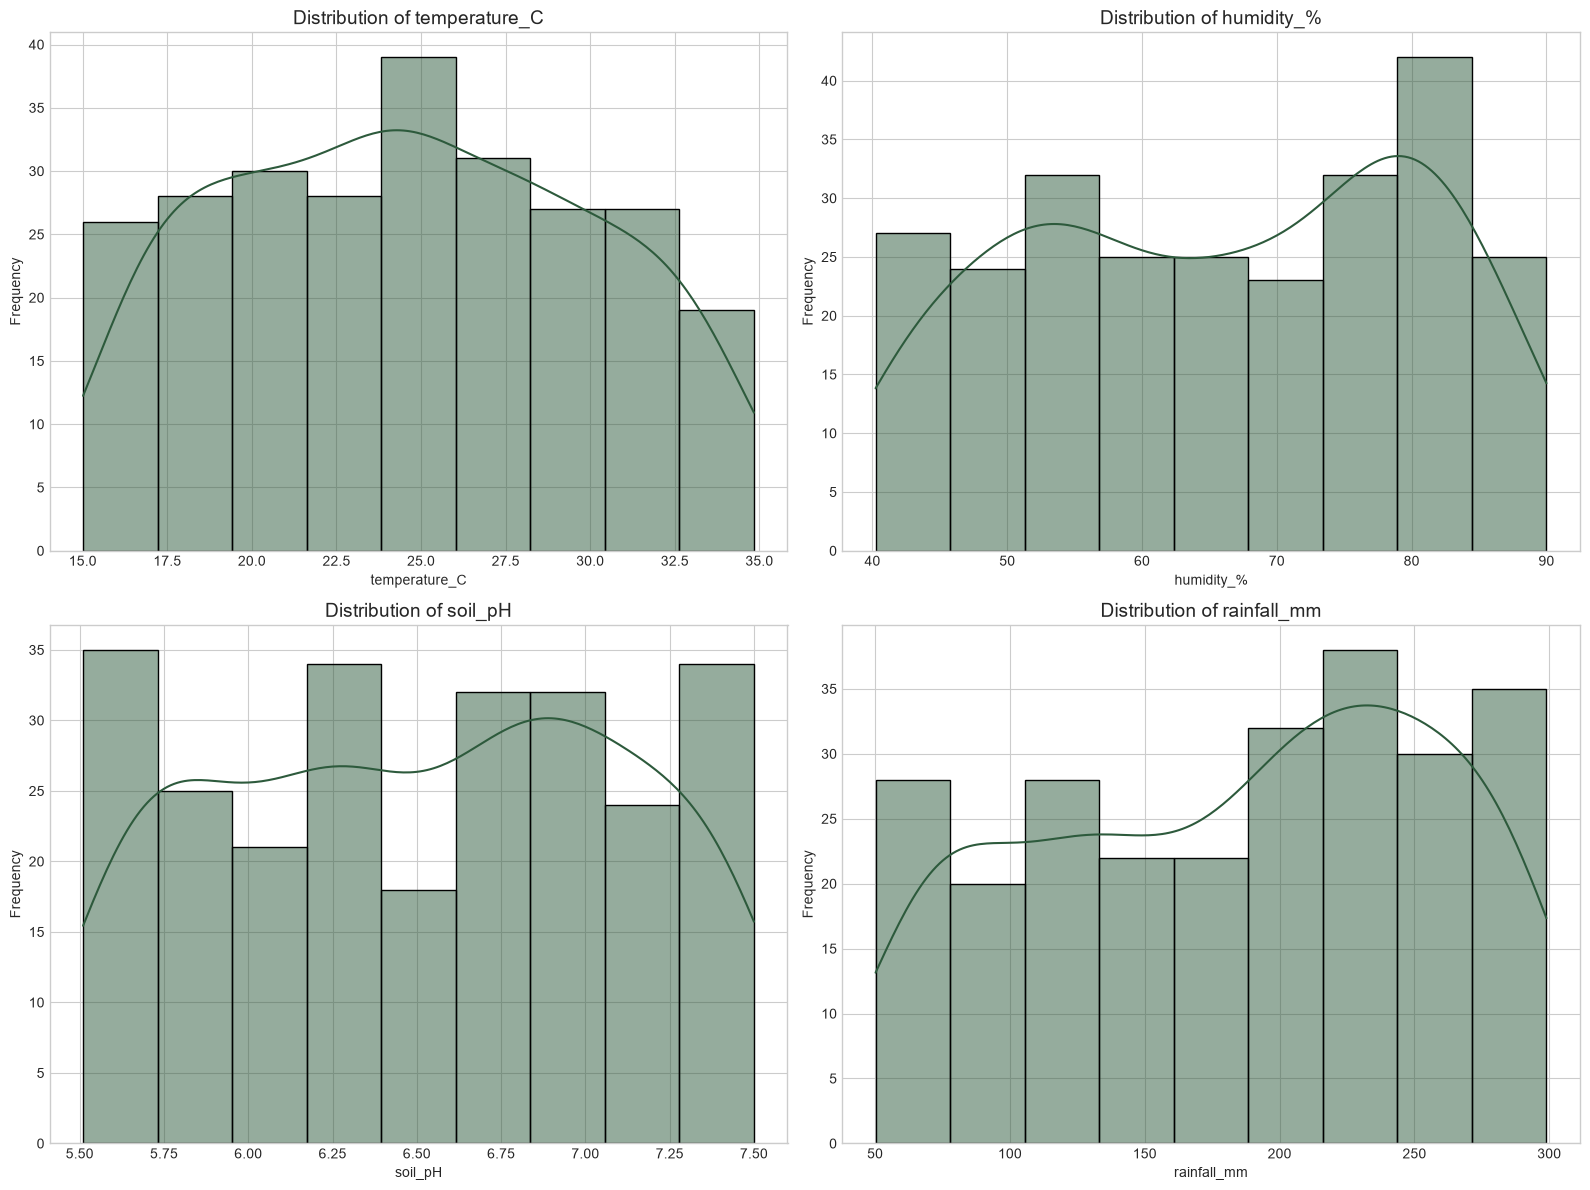

In [20]:
# Updated to match your exact column names
features_to_plot = ['temperature_C', 'humidity_%', 'soil_pH', 'rainfall_mm']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='#2D5A3C')
    axes[i].set_title(f'Distribution of {feature}', fontsize=14)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

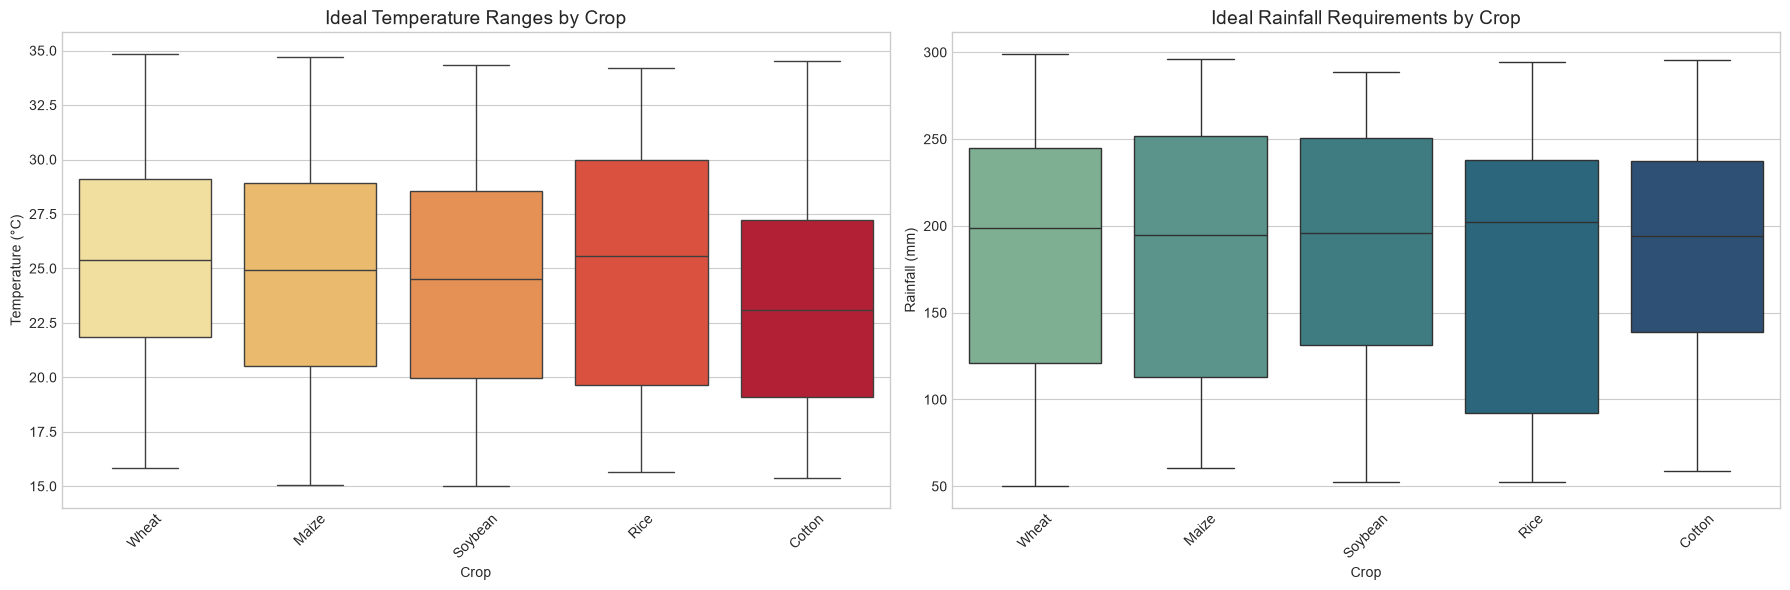

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Temperature vs Crop
sns.boxplot(data=df, x='crop_type', y='temperature_C', ax=axes[0], palette='YlOrRd')
axes[0].set_title('Ideal Temperature Ranges by Crop', fontsize=14)
axes[0].set_xlabel('Crop')
axes[0].set_ylabel('Temperature (°C)')
axes[0].tick_params(axis='x', rotation=45)

# Rainfall vs Crop
sns.boxplot(data=df, x='crop_type', y='rainfall_mm', ax=axes[1], palette='crest')
axes[1].set_title('Ideal Rainfall Requirements by Crop', fontsize=14)
axes[1].set_xlabel('Crop')
axes[1].set_ylabel('Rainfall (mm)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

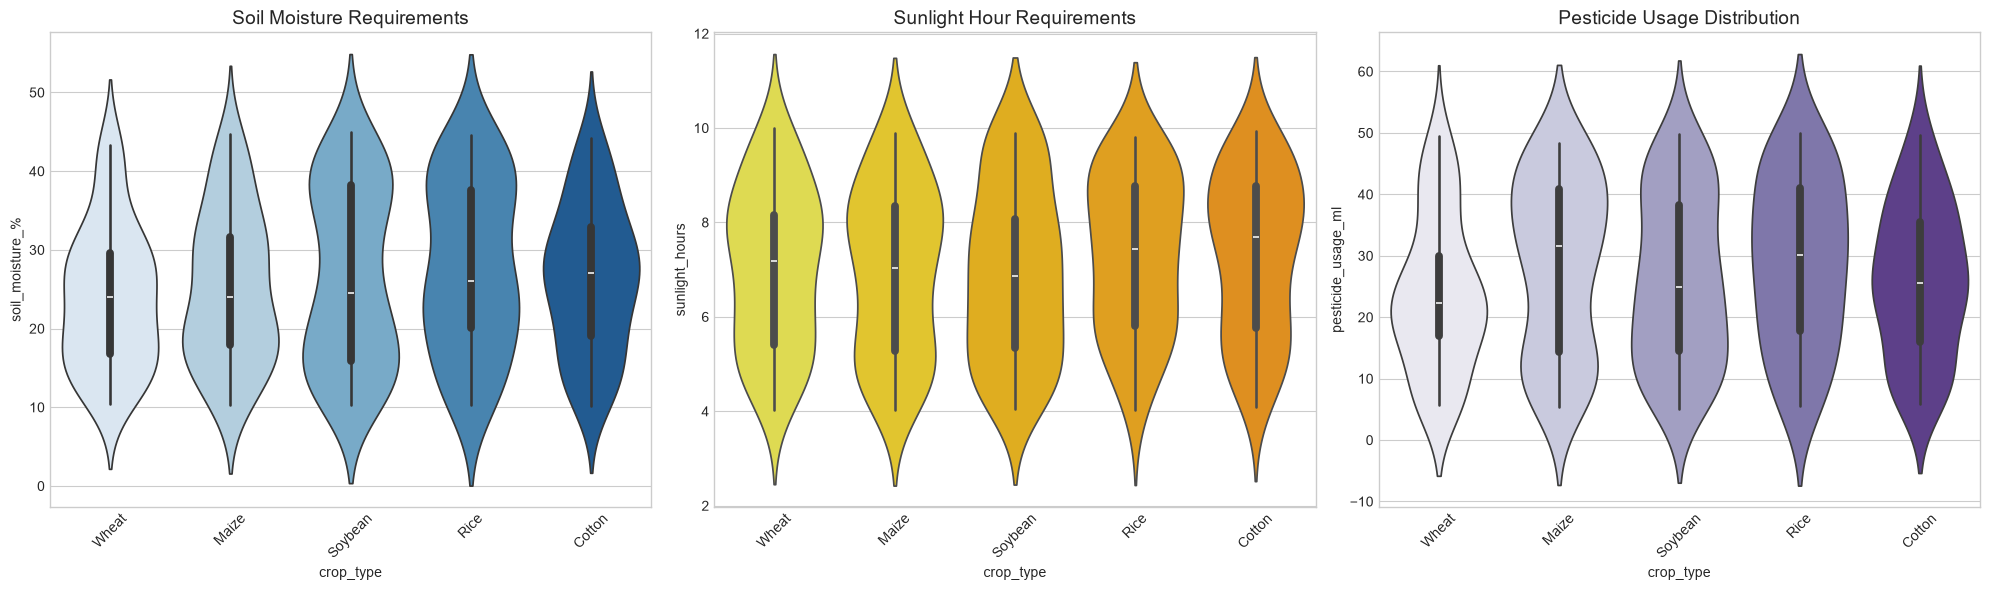

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Soil Moisture
sns.violinplot(data=df, x='crop_type', y='soil_moisture_%', ax=axes[0], palette='Blues')
axes[0].set_title('Soil Moisture Requirements', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Sunlight Hours
sns.violinplot(data=df, x='crop_type', y='sunlight_hours', ax=axes[1], palette='Wistia')
axes[1].set_title('Sunlight Hour Requirements', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# Pesticide Usage
sns.violinplot(data=df, x='crop_type', y='pesticide_usage_ml', ax=axes[2], palette='Purples')
axes[2].set_title('Pesticide Usage Distribution', fontsize=14)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Calculate the ideal ranges using your exact column names
ideal_conditions = df.groupby('crop_type').agg({
    'temperature_C': ['min', 'max', 'mean'],
    'rainfall_mm': ['min', 'max', 'mean'],
    'soil_pH': ['min', 'max', 'mean']
}).round(2)

print("Extracted Environmental Thresholds:")
display(ideal_conditions)

Extracted Environmental Thresholds:


temperature_C               rainfall_mm                 soil_pH  \
                    min    max   mean         min     max    mean     min   
crop_type                                                                   
Cotton            15.39  34.52  23.67       59.00  295.74  190.98    5.51   
Maize             15.04  34.71  24.93       60.55  296.33  184.34    5.51   
Rice              15.64  34.19  24.80       52.35  294.51  174.99    5.60   
Soybean           15.01  34.33  24.53       52.38  288.65  187.80    5.51   
Wheat             15.85  34.84  25.43       50.17  298.96  182.47    5.57   

                       
            max  mean  
crop_type              
Cotton     7.43  6.53  
Maize      7.47  6.52  
Rice       7.49  6.49  
Soybean    7.50  6.52  
Wheat      7.48  6.55

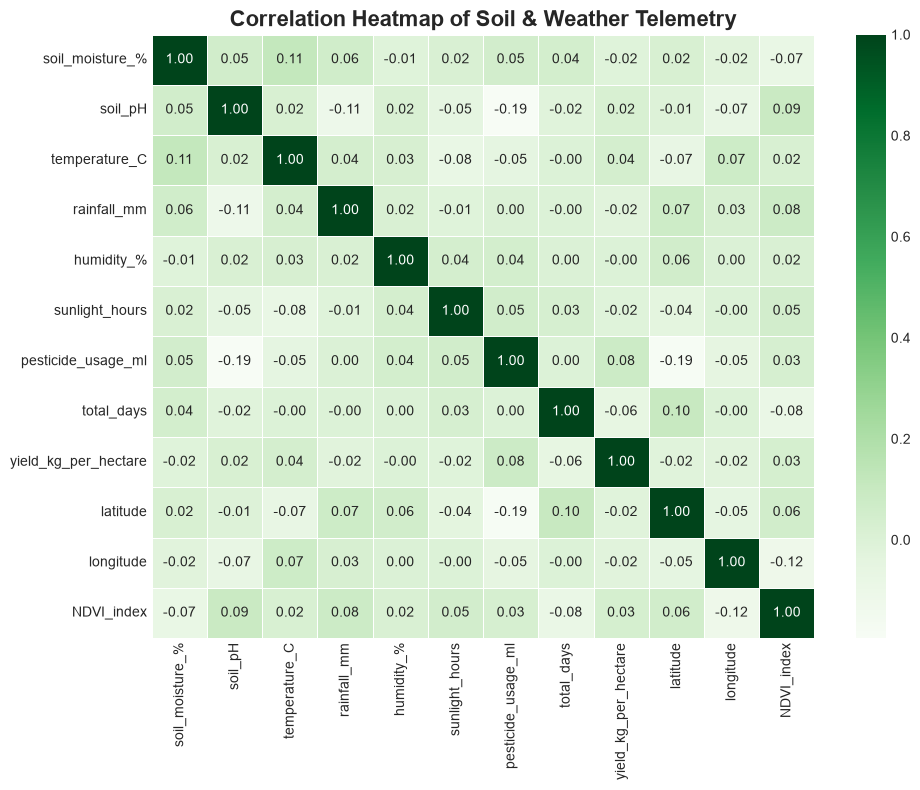

In [26]:
plt.figure(figsize=(10, 8))
# Select only numerical columns for the heatmap
numerical_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Draw heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Greens', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Soil & Weather Telemetry', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()